In [1]:
import pandas as pd
df = pd.read_parquet("../data/processed/caries_features.parquet")
demo_df = pd.read_sas("../data/raw/P_DEMO.XPT")
demo_df = demo_df[["SEQN", "RIDAGEYR", "RIAGENDR"]]
demo_df['is_female'] = (demo_df['RIAGENDR']==2).astype(int)
demo_df = demo_df.drop('RIAGENDR', axis=1)
df = df.merge(demo_df, on='SEQN', how='inner')


In [2]:
X = df[
    [
        "RIDAGEYR",
        "is_female",
        "n_missing_teeth",
        "n_filled_teeth"
    ]
]

y = (df["has_root_caries"] == 1).astype(int)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state=101)

from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000,solver="lbfgs")
model.fit(X_train, y_train)
y_prob = model.predict_proba(X_test)[:, 1]

In [3]:
import numpy as np
import pandas as pd
from sklearn.metrics import recall_score, precision_score, f1_score

def threshold_metrics_table(y_true, y_prob, thresholds):
    rows = []
    for t in thresholds:
        preds = (y_prob >= t).astype(int)
        rows.append({
            "threshold": t,
            "recall": recall_score(y_true, preds, zero_division=0),
            "precision": precision_score(y_true, preds, zero_division=0),
            "f1": f1_score(y_true, preds, zero_division=0)
        })
    return pd.DataFrame(rows)

In [4]:
thresholds = np.linspace(0.01, 0.5, 100)
df_thresh = threshold_metrics_table(y_test, y_prob, thresholds)

df_thresh.head()

,threshold,recall,precision,f1
0,0.010000,1.000000,0.078673,0.145871
1,0.014949,1.000000,0.079657,0.147560
2,0.019899,0.996923,0.087261,0.160475
3,0.024848,0.990769,0.099598,0.181001
4,0.029798,0.972308,0.112336,0.201402


In [5]:
df_thresh.sort_values("recall", ascending=False).head()

,threshold,recall,precision,f1
0,0.010000,1.000000,0.078673,0.145871
1,0.014949,1.000000,0.079657,0.147560
2,0.019899,0.996923,0.087261,0.160475
3,0.024848,0.990769,0.099598,0.181001
4,0.029798,0.972308,0.112336,0.201402


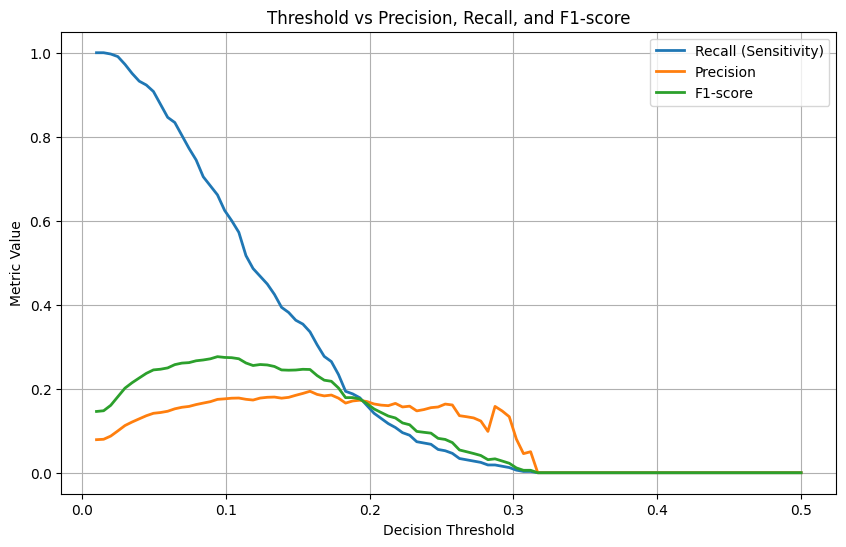

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(df_thresh["threshold"], df_thresh["recall"], label="Recall (Sensitivity)", linewidth=2)
plt.plot(df_thresh["threshold"], df_thresh["precision"], label="Precision", linewidth=2)
plt.plot(df_thresh["threshold"], df_thresh["f1"], label="F1-score", linewidth=2)

plt.xlabel("Decision Threshold")
plt.ylabel("Metric Value")
plt.title("Threshold vs Precision, Recall, and F1-score")
plt.legend()
plt.grid(True)

plt.show()


In [7]:
FINAL_THRESHOLD = 0.10

final_preds = (y_prob >= FINAL_THRESHOLD).astype(int)

from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, final_preds))
print(classification_report(y_test, final_preds))

[[2862  945]
 [ 123  202]]
              precision    recall  f1-score   support

           0       0.96      0.75      0.84      3807
           1       0.18      0.62      0.27       325

    accuracy                           0.74      4132
   macro avg       0.57      0.69      0.56      4132
weighted avg       0.90      0.74      0.80      4132

